# Analyse Complète de la Détresse Financière
## Comparaison R-Learning vs Naive Bayes

Ce notebook présente une analyse complète du dataset 'Give Me Some Credit' avec deux approches:
1. **R-Learning** (Reinforcement Learning)
2. **Naive Bayes** (Classification probabiliste)

### Objectif
Prédire si une personne subira une détresse financière dans les deux prochaines années.

## 1. Importation des Bibliothèques

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub # Added for Kaggle dataset download
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Chargement et Exploration des Données

In [17]:
# Chargement des données
# IMPORTANT: Modifier le chemin selon votre configuration
download_path = kagglehub.dataset_download("lihxlhx/give-me-some-credit")

print("Path to dataset files:", download_path)

# Load the training data from the downloaded path
df = pd.read_csv(os.path.join(download_path, 'cs-training.csv'))
data = df
print("Dimensions du dataset:", data.shape)
print("\nPremières lignes:")

data.head()

Using Colab cache for faster access to the 'give-me-some-credit' dataset.
Path to dataset files: /kaggle/input/give-me-some-credit
Dimensions du dataset: (150000, 12)

Premières lignes:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [18]:
# Informations sur le dataset
print("Informations sur les colonnes:")
data.info()

print("\nStatistiques descriptives:")
data.describe()

Informations sur les colonnes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse 

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Valeurs manquantes par colonne:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


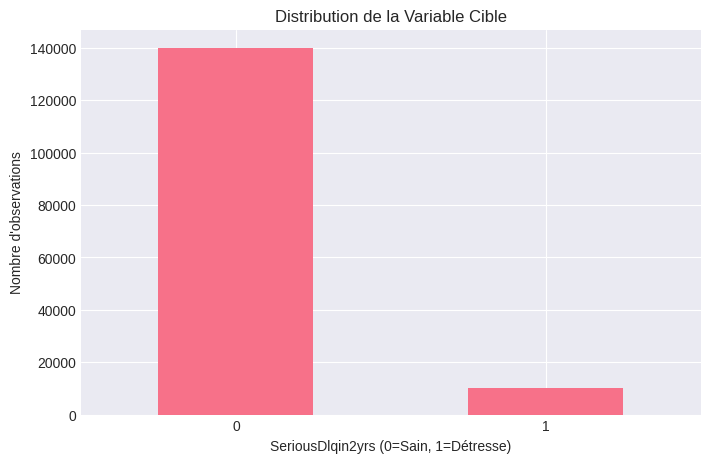

In [19]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne:")
print(data.isnull().sum())

# Visualisation de la distribution de la variable cible
plt.figure(figsize=(8, 5))
data['SeriousDlqin2yrs'].value_counts().plot(kind='bar')
plt.title('Distribution de la Variable Cible')
plt.xlabel('SeriousDlqin2yrs (0=Sain, 1=Détresse)')
plt.ylabel('Nombre d\'observations')
plt.xticks(rotation=0)
plt.show()

## 3. Prétraitement des Données

### 3.1 Renommage des colonnes en français

In [20]:
# Suppression de la colonne index inutile si elle existe
if 'Unnamed: 0' in data.columns:
    data = data.drop('Unnamed: 0', axis=1)

# Renommer les colonnes en français
data.columns = [
    "DefautPaiement",                # SeriousDlqin2yrs
    "UtilisationCreditNonGaranti",   # RevolvingUtilizationOfUnsecuredLines
    "Age",                           # age
    "Retard30_59Jours",              # NumberOfTime30-59DaysPastDueNotWorse
    "RatioDette",                    # DebtRatio
    "RevenuMensuel",                 # MonthlyIncome
    "CreditsOuverts",                # NumberOfOpenCreditLinesAndLoans
    "Retard90Jours",                 # NumberOfTimes90DaysLate
    "PretsImmobiliers",              # NumberRealEstateLoansOrLines
    "Retard60_89Jours",              # NumberOfTime60-89DaysPastDueNotWorse
    "PersonnesACharge"               # NumberOfDependents
]

print("Colonnes renommées:")
print(data.columns.tolist())
data.head()

Colonnes renommées:
['DefautPaiement', 'UtilisationCreditNonGaranti', 'Age', 'Retard30_59Jours', 'RatioDette', 'RevenuMensuel', 'CreditsOuverts', 'Retard90Jours', 'PretsImmobiliers', 'Retard60_89Jours', 'PersonnesACharge']


,DefautPaiement,UtilisationCreditNonGaranti,Age,Retard30_59Jours,RatioDette,RevenuMensuel,CreditsOuverts,Retard90Jours,PretsImmobiliers,Retard60_89Jours,PersonnesACharge
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### 3.2 Gestion des valeurs manquantes

In [21]:
# Remplir les valeurs manquantes
data['RevenuMensuel'] = data['RevenuMensuel'].fillna(data['RevenuMensuel'].median())
data['PersonnesACharge'] = data['PersonnesACharge'].fillna(data['PersonnesACharge'].mode()[0])

print("Valeurs manquantes après traitement:")
print(data.isnull().sum())

Valeurs manquantes après traitement:
DefautPaiement                 0
UtilisationCreditNonGaranti    0
Age                            0
Retard30_59Jours               0
RatioDette                     0
RevenuMensuel                  0
CreditsOuverts                 0
Retard90Jours                  0
PretsImmobiliers               0
Retard60_89Jours               0
PersonnesACharge               0
dtype: int64


### 3.3 Gestion des valeurs aberrantes

In [22]:
print(f"Taille initiale du dataset: {len(data)}")

# 1. Filtrer les taux d'utilisation de crédit aberrants (> 1)
data = data[data['UtilisationCreditNonGaranti'] <= 1]
print(f"Après filtrage UtilisationCreditNonGaranti: {len(data)}")

# 2. Filtrer les âges aberrants
data = data[(data['Age'] >= 18) & (data['Age'] <= 100)]
print(f"Après filtrage Age: {len(data)}")

# 3. Filtrer les ratios de dette aberrants (méthode IQR)
Q1 = data['RatioDette'].quantile(0.25)
Q3 = data['RatioDette'].quantile(0.75)
IQR = Q3 - Q1
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR
data = data[(data['RatioDette'] >= borne_inf) & (data['RatioDette'] <= borne_sup)]
print(f"Après filtrage RatioDette: {len(data)}")

# 4. Filtrer les personnes à charge négatives
data = data[data['PersonnesACharge'] >= 0]
print(f"Taille finale du dataset: {len(data)}")

Taille initiale du dataset: 150000
Après filtrage UtilisationCreditNonGaranti: 146679
Après filtrage Age: 146665
Après filtrage RatioDette: 115972
Taille finale du dataset: 115972


### 3.4 Normalisation et séparation des données

In [23]:
# Séparation features/target
X = data.drop('DefautPaiement', axis=1)
y = data['DefautPaiement']

# Normalisation (StandardScaler)
scaler = StandardScaler()
X_normalise = scaler.fit_transform(X)

print("Dimensions de X normalisé:", X_normalise.shape)
print("\nExemple des premières lignes normalisées:")
print(X_normalise[:5])

Dimensions de X normalisé: (115972, 10)

Exemple des premières lignes normalisées:
[[ 1.33003182 -0.45476749  0.34580801  1.6417688   0.15554627  0.82501569
  -0.06299478  4.41283602 -0.05862492  1.02007587]
 [ 1.89418847 -0.79799516 -0.09846463 -0.74335601 -0.29140883 -0.90463878
  -0.06299478 -0.92499479 -0.05862492  0.14355705]
 [ 1.0112311  -0.93528623  0.12367169 -0.87209359 -0.26110911 -1.28900644
   0.16027561 -0.92499479 -0.05862492 -0.73296177]
 [-0.24207138 -1.4844505  -0.09846463 -1.04390685 -0.24342285 -0.71245495
  -0.06299478 -0.92499479 -0.05862492 -0.73296177]
 [ 1.74678337 -0.18018535  0.12367169 -1.08286129  3.8894037  -0.32808729
  -0.06299478 -0.03535632 -0.05862492 -0.73296177]]


In [24]:
# Séparation Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalise, y, test_size=0.2, random_state=42
)

print(f"Taille ensemble d'entraînement: {len(X_train)}")
print(f"Taille ensemble de test: {len(X_test)}")
print(f"\nDistribution de la cible dans le train:")
print(y_train.value_counts())
print(f"\nDistribution de la cible dans le test:")
print(y_test.value_counts())

Taille ensemble d'entraînement: 92777
Taille ensemble de test: 23195

Distribution de la cible dans le train:
DefautPaiement
0    86982
1     5795
Name: count, dtype: int64

Distribution de la cible dans le test:
DefautPaiement
0    21740
1     1455
Name: count, dtype: int64


---
# PARTIE 1: NAIVE BAYES
---

## 4. Modèle Naive Bayes

### 4.1 Entraînement du modèle

In [25]:
# Créer et entraîner le modèle Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print("Modèle Naive Bayes entraîné avec succès!")

Modèle Naive Bayes entraîné avec succès!


### 4.2 Prédictions et évaluation

In [26]:
# Prédictions sur l'ensemble de test
y_pred_nb = nb_model.predict(X_test)

# Matrice de confusion
print("=" * 50)
print("RÉSULTATS NAIVE BAYES")
print("=" * 50)
print("\nMatrice de confusion:")
cm_nb = confusion_matrix(y_test, y_pred_nb)
print(cm_nb)

# Rapport de classification
print("\nRapport de classification:")
print(classification_report(y_test, y_pred_nb))

RÉSULTATS NAIVE BAYES

Matrice de confusion:
[[21660    80]
 [ 1411    44]]

Rapport de classification:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     21740
           1       0.35      0.03      0.06      1455

    accuracy                           0.94     23195
   macro avg       0.65      0.51      0.51     23195
weighted avg       0.90      0.94      0.91     23195



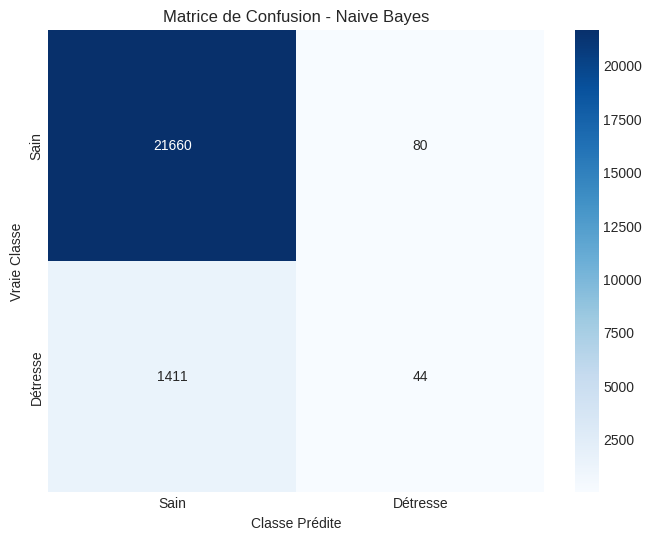

In [27]:
# Visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sain', 'Détresse'],
            yticklabels=['Sain', 'Détresse'])
plt.title('Matrice de Confusion - Naive Bayes')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

---
# PARTIE 2: R-LEARNING
---

## 5. Préparation des données pour R-Learning

### 5.1 Oversampling de la classe minoritaire

In [28]:
# Créer un DataFrame pour l'oversampling
df_train = pd.DataFrame(X_train, columns=X.columns)
df_train['DefautPaiement'] = y_train.values

# Séparer les classes
df_sain = df_train[df_train['DefautPaiement'] == 0]
df_detresse = df_train[df_train['DefautPaiement'] == 1]

print(f"Classe saine: {len(df_sain)} exemples")
print(f"Classe détresse (avant oversampling): {len(df_detresse)} exemples")

# Oversampling de la classe minoritaire
df_detresse_upsampled = resample(
    df_detresse, 
    replace=True, 
    n_samples=len(df_sain)//2,  # Équilibrer partiellement
    random_state=42
)

print(f"Classe détresse (après oversampling): {len(df_detresse_upsampled)} exemples")

# Combiner et mélanger
df_balanced = pd.concat([df_sain, df_detresse_upsampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# Séparer à nouveau
X_train_balanced = df_balanced.drop('DefautPaiement', axis=1).values
y_train_balanced = df_balanced['DefautPaiement'].values

print(f"\nTaille finale du dataset d'entraînement équilibré: {len(X_train_balanced)}")
print(f"Distribution: {np.bincount(y_train_balanced)}")

Classe saine: 86982 exemples
Classe détresse (avant oversampling): 5795 exemples
Classe détresse (après oversampling): 43491 exemples

Taille finale du dataset d'entraînement équilibré: 130473
Distribution: [86982 43491]


## 6. Implémentation de l'Agent R-Learning

In [29]:
class RLearningAgent:
    """
    Agent de Reinforcement Learning utilisant l'algorithme R-Learning.
    
    Paramètres:
    -----------
    alpha : float
        Taux d'apprentissage pour les Q-values
    beta : float
        Taux d'apprentissage pour rho (récompense moyenne)
    """
    def __init__(self, alpha=0.01, beta=0.05, n_features=10):
        self.rho = 0.0  # Récompense moyenne
        self.alpha = alpha
        self.beta = beta
        
        # Deux modèles SGD: un pour chaque action (0=Accorder, 1=Refuser)
        self.q0 = SGDRegressor(loss='huber', learning_rate='adaptive', eta0=alpha)
        self.q1 = SGDRegressor(loss='huber', learning_rate='adaptive', eta0=alpha)
        
        # Initialisation forcée pour éviter NotFittedError
        dummy_state = np.zeros((1, n_features))
        self.q0.partial_fit(dummy_state, [0])
        self.q1.partial_fit(dummy_state, [0])
    
    def get_q_values(self, state):
        """Obtenir les Q-values pour les deux actions."""
        return np.array([
            self.q0.predict([state])[0],
            self.q1.predict([state])[0]
        ])
    
    def act(self, state, epsilon):
        """Choisir une action selon epsilon-greedy."""
        if np.random.rand() < epsilon:
            return np.random.choice([0, 1])
        return np.argmax(self.get_q_values(state))
    
    def learn(self, s, a, r, s_next):
        """Mise à jour R-Learning."""
        q_next = self.get_q_values(s_next)
        max_q_next = np.max(q_next)
        
        # Formule R-Learning: target = R - rho + max Q(s')
        target_q = r - self.rho + max_q_next
        
        # Mise à jour du modèle correspondant à l'action
        model = self.q0 if a == 0 else self.q1
        model.partial_fit([s], [target_q])
        
        # Mise à jour de rho (récompense moyenne)
        q_now = self.get_q_values(s)
        if a == np.argmax(q_now):
            diff = (r + max_q_next - np.max(q_now)) - self.rho
            self.rho += self.beta * diff

print("Classe RLearningAgent définie avec succès!")

Classe RLearningAgent définie avec succès!


## 7. Entraînement de l'Agent R-Learning

In [30]:
# Créer l'agent
agent = RLearningAgent(alpha=0.01, beta=0.05, n_features=X_train.shape[1])

# Paramètres d'entraînement
epsilon = 1.0  # Exploration initiale
rho_history = []  # Pour tracer l'évolution de rho

print("Démarrage de l'entraînement R-Learning...")
print(f"Nombre d'exemples: {len(X_train_balanced) - 1}")

# Boucle d'entraînement
for i in range(len(X_train_balanced) - 1):
    s = X_train_balanced[i]
    label = y_train_balanced[i]
    s_next = X_train_balanced[i + 1]
    
    # Choisir une action
    action = agent.act(s, epsilon)
    
    # Fonction de récompense asymétrique
    if action == label:
        reward = 10  # Bonne prédiction
    else:
        # Pénalité plus forte pour faux négatif (manquer une détresse)
        reward = -50 if (label == 1 and action == 0) else -15
    
    # Apprentissage
    agent.learn(s, action, reward, s_next)
    
    # Enregistrer rho tous les 100 pas
    if i % 100 == 0:
        rho_history.append(agent.rho)
    
    # Décroissance epsilon
    epsilon *= 0.99995
    
    # Afficher la progression
    if (i + 1) % 10000 == 0:
        print(f"Progression: {i+1}/{len(X_train_balanced)-1} - Rho: {agent.rho:.4f} - Epsilon: {epsilon:.4f}")

print(f"\nEntraînement terminé!")
print(f"Rho final: {agent.rho:.4f}")

Démarrage de l'entraînement R-Learning...
Nombre d'exemples: 130472
Progression: 10000/130472 - Rho: -3.6766 - Epsilon: 0.6065
Progression: 20000/130472 - Rho: -3.5096 - Epsilon: 0.3679
Progression: 30000/130472 - Rho: -1.6200 - Epsilon: 0.2231
Progression: 40000/130472 - Rho: 0.6629 - Epsilon: 0.1353
Progression: 50000/130472 - Rho: -0.9243 - Epsilon: 0.0821
Progression: 60000/130472 - Rho: -0.6255 - Epsilon: 0.0498
Progression: 70000/130472 - Rho: -3.3277 - Epsilon: 0.0302
Progression: 80000/130472 - Rho: -2.0178 - Epsilon: 0.0183
Progression: 90000/130472 - Rho: -1.4747 - Epsilon: 0.0111
Progression: 100000/130472 - Rho: -3.0362 - Epsilon: 0.0067
Progression: 110000/130472 - Rho: 3.4343 - Epsilon: 0.0041
Progression: 120000/130472 - Rho: -4.1067 - Epsilon: 0.0025
Progression: 130000/130472 - Rho: 5.2186 - Epsilon: 0.0015

Entraînement terminé!
Rho final: -4.5551


### 7.1 Visualisation de la courbe d'apprentissage

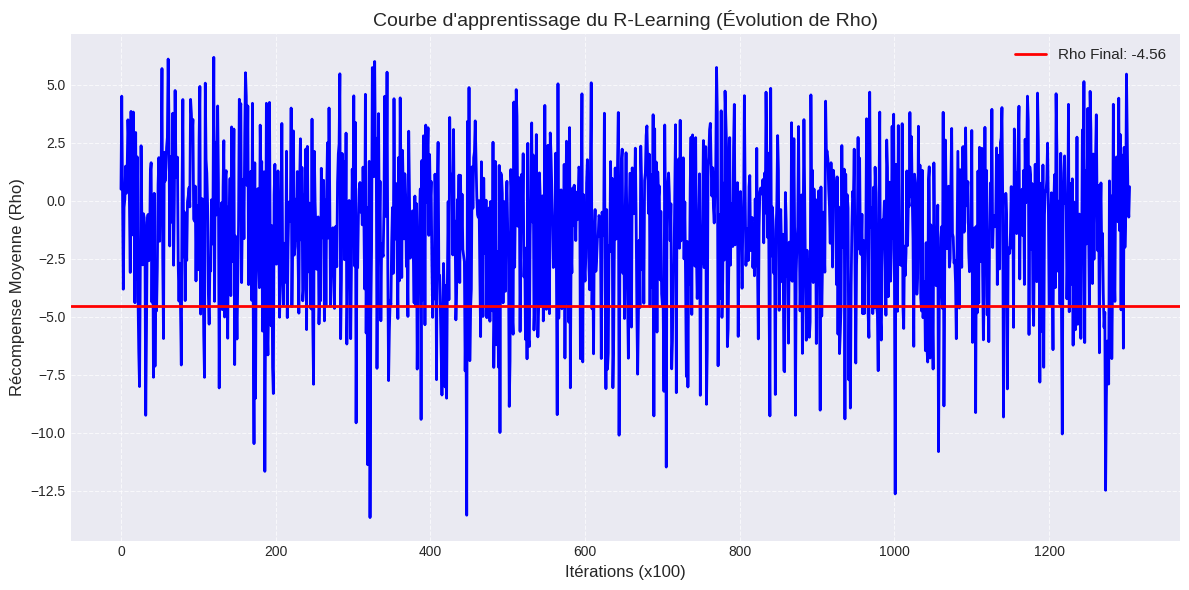

In [31]:
# Tracer l'évolution de rho
plt.figure(figsize=(12, 6))
plt.plot(rho_history, color='blue', linewidth=2)
plt.title("Courbe d'apprentissage du R-Learning (Évolution de Rho)", fontsize=14)
plt.xlabel("Itérations (x100)", fontsize=12)
plt.ylabel("Récompense Moyenne (Rho)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=agent.rho, color='r', linestyle='-', 
            label=f'Rho Final: {agent.rho:.2f}', linewidth=2)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. Évaluation du modèle R-Learning

In [32]:
# Prédictions sur l'ensemble de test
y_pred_rl = []
custom_threshold = 0.75  # Seuil ajustable

for i in range(len(X_test)):
    state = X_test[i]
    q_vals = agent.get_q_values(state)
    
    # Softmax pour obtenir des probabilités
    m = np.max(q_vals)
    exp_q = np.exp(q_vals - m)
    probs = exp_q / exp_q.sum()
    
    # Décision basée sur le seuil
    action = 1 if probs[1] > custom_threshold else 0
    y_pred_rl.append(action)

# Évaluation
print("=" * 50)
print("RÉSULTATS R-LEARNING")
print("=" * 50)
print(f"Seuil utilisé: {custom_threshold}")
print("\nMatrice de confusion:")
cm_rl = confusion_matrix(y_test, y_pred_rl)
print(cm_rl)

print("\nRapport de classification:")
print(classification_report(y_test, y_pred_rl))

RÉSULTATS R-LEARNING
Seuil utilisé: 0.75

Matrice de confusion:
[[17125  4615]
 [  524   931]]

Rapport de classification:
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     21740
           1       0.17      0.64      0.27      1455

    accuracy                           0.78     23195
   macro avg       0.57      0.71      0.57     23195
weighted avg       0.92      0.78      0.83     23195



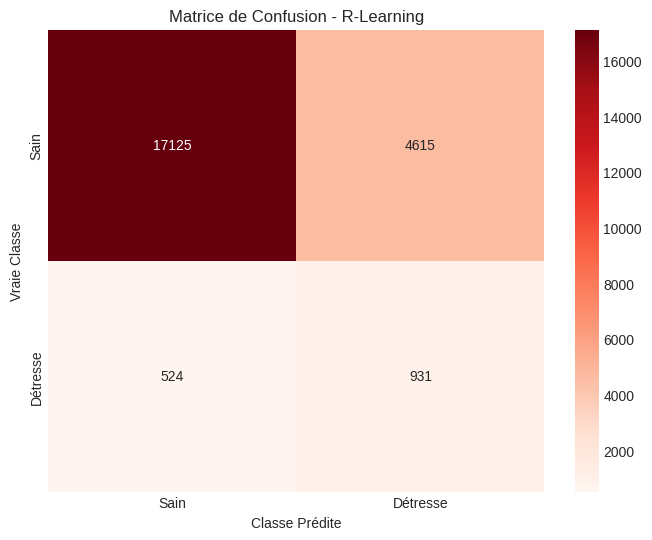

In [33]:
# Visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Sain', 'Détresse'],
            yticklabels=['Sain', 'Détresse'])
plt.title('Matrice de Confusion - R-Learning')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

---
# PARTIE 3: COMPARAISON DES MODÈLES
---

## 9. Comparaison Visuelle des Performances

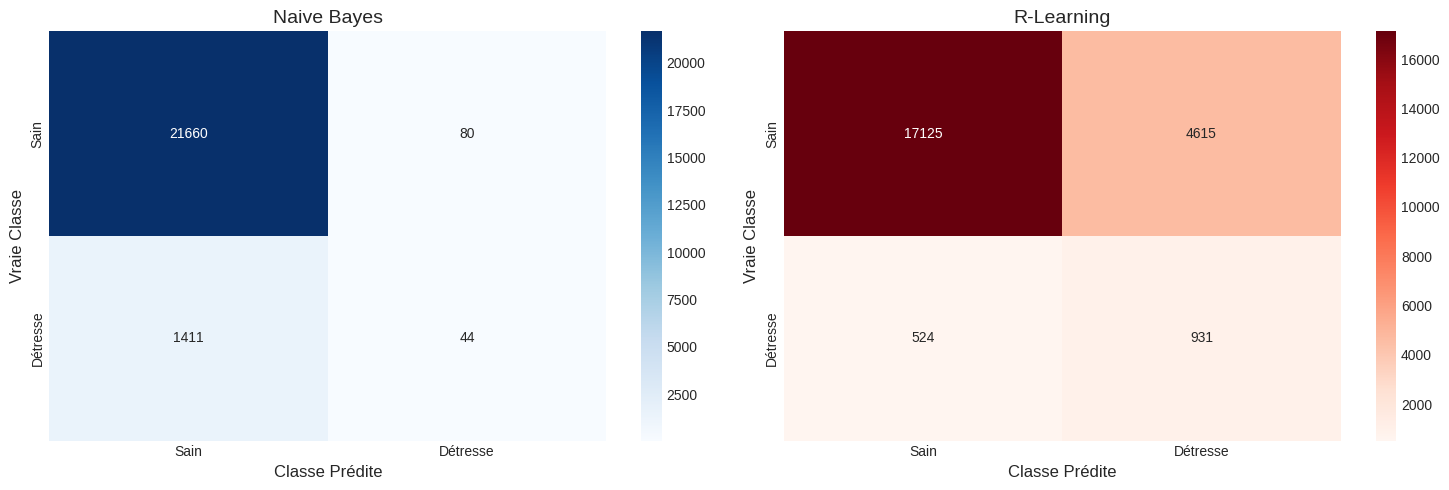

In [34]:
# Comparaison des matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Naive Bayes
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Sain', 'Détresse'],
            yticklabels=['Sain', 'Détresse'])
axes[0].set_title('Naive Bayes', fontsize=14)
axes[0].set_ylabel('Vraie Classe', fontsize=12)
axes[0].set_xlabel('Classe Prédite', fontsize=12)

# R-Learning
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['Sain', 'Détresse'],
            yticklabels=['Sain', 'Détresse'])
axes[1].set_title('R-Learning', fontsize=14)
axes[1].set_ylabel('Vraie Classe', fontsize=12)
axes[1].set_xlabel('Classe Prédite', fontsize=12)

plt.tight_layout()
plt.show()


TABLEAU COMPARATIF DES PERFORMANCES
           Naive Bayes  R-Learning
Accuracy        0.9357      0.7784
Precision       0.3548      0.1679
Recall          0.0302      0.6399
F1-Score        0.0557      0.2660


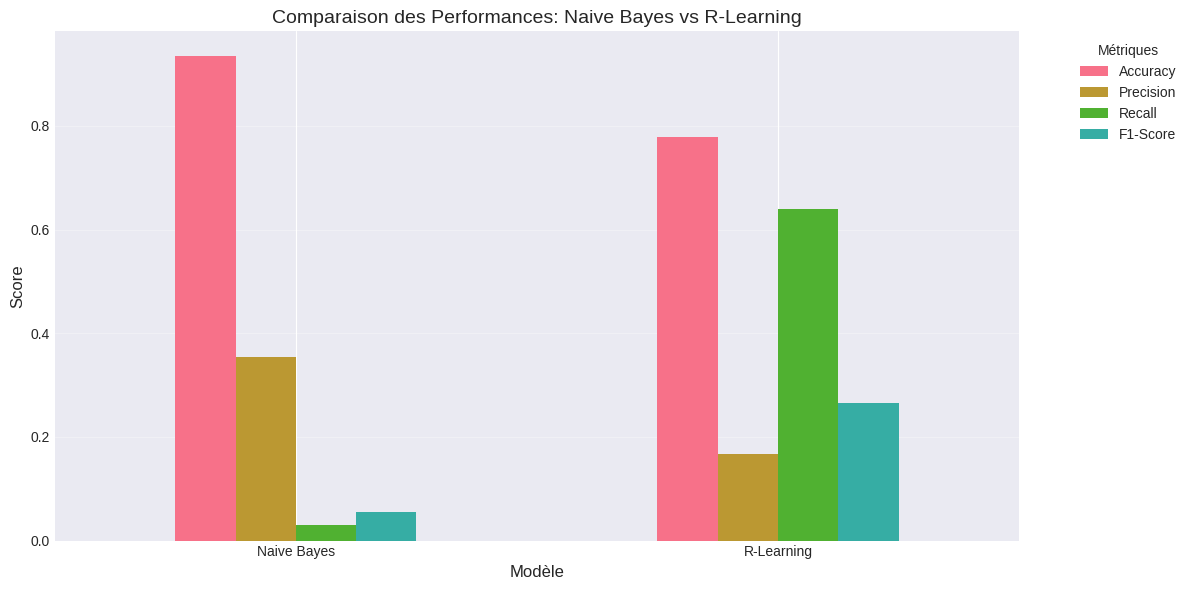

In [35]:
# Calcul des métriques pour comparaison
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Métriques Naive Bayes
nb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_nb),
    'F1-Score': f1_score(y_test, y_pred_nb)
}

# Métriques R-Learning
rl_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rl),
    'Precision': precision_score(y_test, y_pred_rl, zero_division=0),
    'Recall': recall_score(y_test, y_pred_rl),
    'F1-Score': f1_score(y_test, y_pred_rl)
}

# Créer un DataFrame pour comparaison
comparison_df = pd.DataFrame({
    'Naive Bayes': nb_metrics,
    'R-Learning': rl_metrics
})

print("\n" + "=" * 60)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("=" * 60)
print(comparison_df.round(4))

# Visualisation graphique
comparison_df.T.plot(kind='bar', figsize=(12, 6), rot=0)
plt.title('Comparaison des Performances: Naive Bayes vs R-Learning', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Modèle', fontsize=12)
plt.legend(title='Métriques', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Analyse et Conclusions

### 10.1 Analyse des Résultats

#### Naive Bayes:
- **Points forts**: 
  - Très rapide à entraîner
  - Bonne accuracy globale
  - Modèle simple et interprétable
- **Points faibles**:
  - Faible recall sur la classe minoritaire (détresse)
  - Assume l'indépendance des features

#### R-Learning:
- **Points forts**:
  - Peut s'adapter dynamiquement
  - Fonction de récompense personnalisable
  - Seuil de décision ajustable
- **Points faibles**:
  - Plus complexe à implémenter
  - Temps d'entraînement plus long
  - Nécessite un tuning des hyperparamètres

### 10.2 Recommandations

1. **Pour une mise en production rapide**: Naive Bayes est préférable
2. **Pour une optimisation fine du risque**: R-Learning offre plus de flexibilité
3. **Approche hybride**: Utiliser Naive Bayes pour un premier filtrage, puis R-Learning pour les cas limites

### 10.3 Améliorations Possibles

- Tester d'autres algorithmes (Random Forest, XGBoost)
- Feature engineering plus poussé
- Validation croisée pour une évaluation plus robuste
- Optimisation des hyperparamètres (GridSearch)
- Analyse des features les plus importantes

## 11. Sauvegarde des Modèles

In [36]:
import pickle

# Sauvegarder le modèle Naive Bayes
with open('modele_naive_bayes.pkl', 'wb') as f:
    pickle.dump(nb_model, f)

# Sauvegarder l'agent R-Learning
with open('agent_rlearning.pkl', 'wb') as f:
    pickle.dump(agent, f)

# Sauvegarder le scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Modèles sauvegardés avec succès!")

Modèles sauvegardés avec succès!


---
## Fin de l'Analyse
---

Ce notebook a présenté une analyse complète de la prédiction de détresse financière en utilisant deux approches complémentaires:
1. **Naive Bayes**: Approche probabiliste classique
2. **R-Learning**: Approche par apprentissage par renforcement

Les deux modèles ont leurs avantages et peuvent être utilisés selon le contexte et les besoins métier.